<a href="https://colab.research.google.com/github/jaykkim1/KNOC_KPA_2026/blob/main/%5BKPA%5D_%EC%B4%88%EB%B3%B4%EC%9E%90%EB%A5%BC_%EC%9C%84%ED%95%9C_%ED%8C%8C%EC%9D%B4%EC%8D%AC_%EC%BD%94%EB%94%A9_%EB%B0%8F_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_%EC%8B%A4%EC%8A%B5_Day3_%EC%8B%A4%EC%8A%B5%EB%85%B8%ED%8A%B8%EB%B6%81_%EB%B0%B0%ED%8F%AC%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3. 머신러닝 실습 — 실습 노트북

강의자료(Day3_머신러닝실습.pptx) 슬라이드 순서와 맞춰져 있습니다.

## 시작하기 전에
1. 이 노트북을 본인 구글 드라이브에 사본으로 저장하세요.
2. `Day3_실습데이터.zip`을 업로드하고 압축을 풀어주세요.
3. MNIST 데이터셋은 실습 중 인터넷에서 자동으로 다운로드됩니다 (Colab은 문제 없음).


In [ ]:
!git clone https://github.com/jaykkim1/KNOC_KPA_2026.git /content/repo

Cloning into '/content/repo'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 32 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 1.08 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
# 실습 데이터 업로드 & 압축 풀기
from google.colab import files
uploaded = files.upload()  # Day3_실습데이터.zip 선택해서 업로드

import zipfile, os
zip_name = list(uploaded.keys())[0]  # 실제 업로드된 파일명을 그대로 사용
                                       # (Colab이 이름을 바꿔 저장해도(예: "(1)") 안전하게 동작)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("압축 해제 완료:", os.listdir("."))

Saving Day3_실습데이터.zip to Day3_실습데이터.zip
압축 해제 완료: ['.config', 'repo', '직원명단.xlsx', '실적_전체.xlsx', 'Day3_실습데이터.zip', 'sample_data']


In [ ]:
# 한글 폰트 설정 (그래프 한글 깨짐 방지)
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.font_manager as fm
fontpath = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(fontpath)

import matplotlib.pyplot as plt
plt.rc("font", family=fm.FontProperties(fname=fontpath).get_name())
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
import pandas as pd
import numpy as np

emp = pd.read_excel("직원명단.xlsx")
perf = pd.read_excel("실적_전체.xlsx")
emp.head()

,사번,이름,부서,입사일,나이,최근교육이수여부
0,1001,김민수,영업,2024-10,34,Y
1,1002,이서연,개발,2023-04,52,N
2,1003,박지훈,인사,2020-06,33,Y
3,1004,최하은,재무,2012-01,39,N
4,1005,정도윤,마케팅,2012-02,24,N


---
# Part IV-1. 머신러닝 이론 기초

## 데이터를 나누는 이유 — train/test split  (슬라이드 9)
먼저 직원명단에서 '근속년수'라는 새로운 특징(feature)을 만듭니다.
근속년수 하나만 쓰지 않고, **나이·부서까지 함께** 사용해봅니다.

In [ ]:
from sklearn.model_selection import train_test_split

emp["입사년"] = emp["입사일"].astype(str).str.slice(0, 4).astype(int)
emp["근속년수"] = 2026 - emp["입사년"]

# 부서(범주형)를 숫자로 바꾸고, 근속년수·나이와 합쳐서 특성 3종 구성
dept_dummies = pd.get_dummies(emp["부서"], prefix="부서")
X = pd.concat([emp[["근속년수", "나이"]], dept_dummies], axis=1)
y = emp["최근교육이수여부"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))
# print(X.columns.tolist())
print(X.columns)

80 20
Index(['근속년수', '나이', '부서_개발', '부서_마케팅', '부서_영업', '부서_인사', '부서_재무'], dtype='object')


In [ ]:
X_train

,근속년수,나이,부서_개발,부서_마케팅,부서_영업,부서_인사,부서_재무
55,12,52,False,False,True,False,False
88,3,45,False,False,False,False,True
26,5,33,True,False,False,False,False
42,8,30,False,False,False,True,False
69,16,36,False,True,False,False,False
...,...,...,...,...,...,...,...
60,11,29,False,False,True,False,False
71,7,35,True,False,False,False,False
14,9,42,False,True,False,False,False
92,16,52,False,False,False,True,False


In [ ]:
X.columns

Index(['근속년수', '나이', '부서_개발', '부서_마케팅', '부서_영업', '부서_인사', '부서_재무'], dtype='object')

### 개념: 여러 개의 특성(feature)을 함께 쓰면?  (슬라이드 10)
근속년수 하나만 볼 때보다, 나이·부서까지 같이 보면 모델이 판단할 근거가 늘어나 정확도가 오르는 경우가 많습니다.
(다만 관련 없는 특성을 마구 추가하면 오히려 성능이 떨어질 수도 있어요.)

### 범주형 데이터를 숫자로 바꾸기 — get_dummies()  (슬라이드 11)
'부서'처럼 글자로 된 값은 모델에 그대로 넣을 수 없어서, `pd.get_dummies()`로 부서마다 0/1 열을 만들어줍니다.

In [ ]:
dept_dummies = pd.get_dummies(emp["부서"], prefix="부서")
dept_dummies

,부서_개발,부서_마케팅,부서_영업,부서_인사,부서_재무
0,False,False,True,False,False
1,True,False,False,False,False
2,False,False,False,True,False
3,False,False,False,False,True
4,False,True,False,False,False
...,...,...,...,...,...
95,False,False,True,False,False
96,True,False,False,False,False
97,False,False,False,True,False
98,False,False,False,False,True


In [ ]:
emp

,사번,이름,부서,입사일,나이,최근교육이수여부,입사년,근속년수
0,1001,김민수,영업,2024-10,34,Y,2024,2
1,1002,이서연,개발,2023-04,52,N,2023,3
2,1003,박지훈,인사,2020-06,33,Y,2020,6
3,1004,최하은,재무,2012-01,39,N,2012,14
4,1005,정도윤,마케팅,2012-02,24,N,2012,14
...,...,...,...,...,...,...,...,...
95,1096,황채원,영업,2014-12,45,Y,2014,12
96,1097,안시우,개발,2024-06,57,N,2024,2
97,1098,송예린,인사,2011-10,41,Y,2011,15
98,1099,전동현,재무,2017-02,58,Y,2017,9


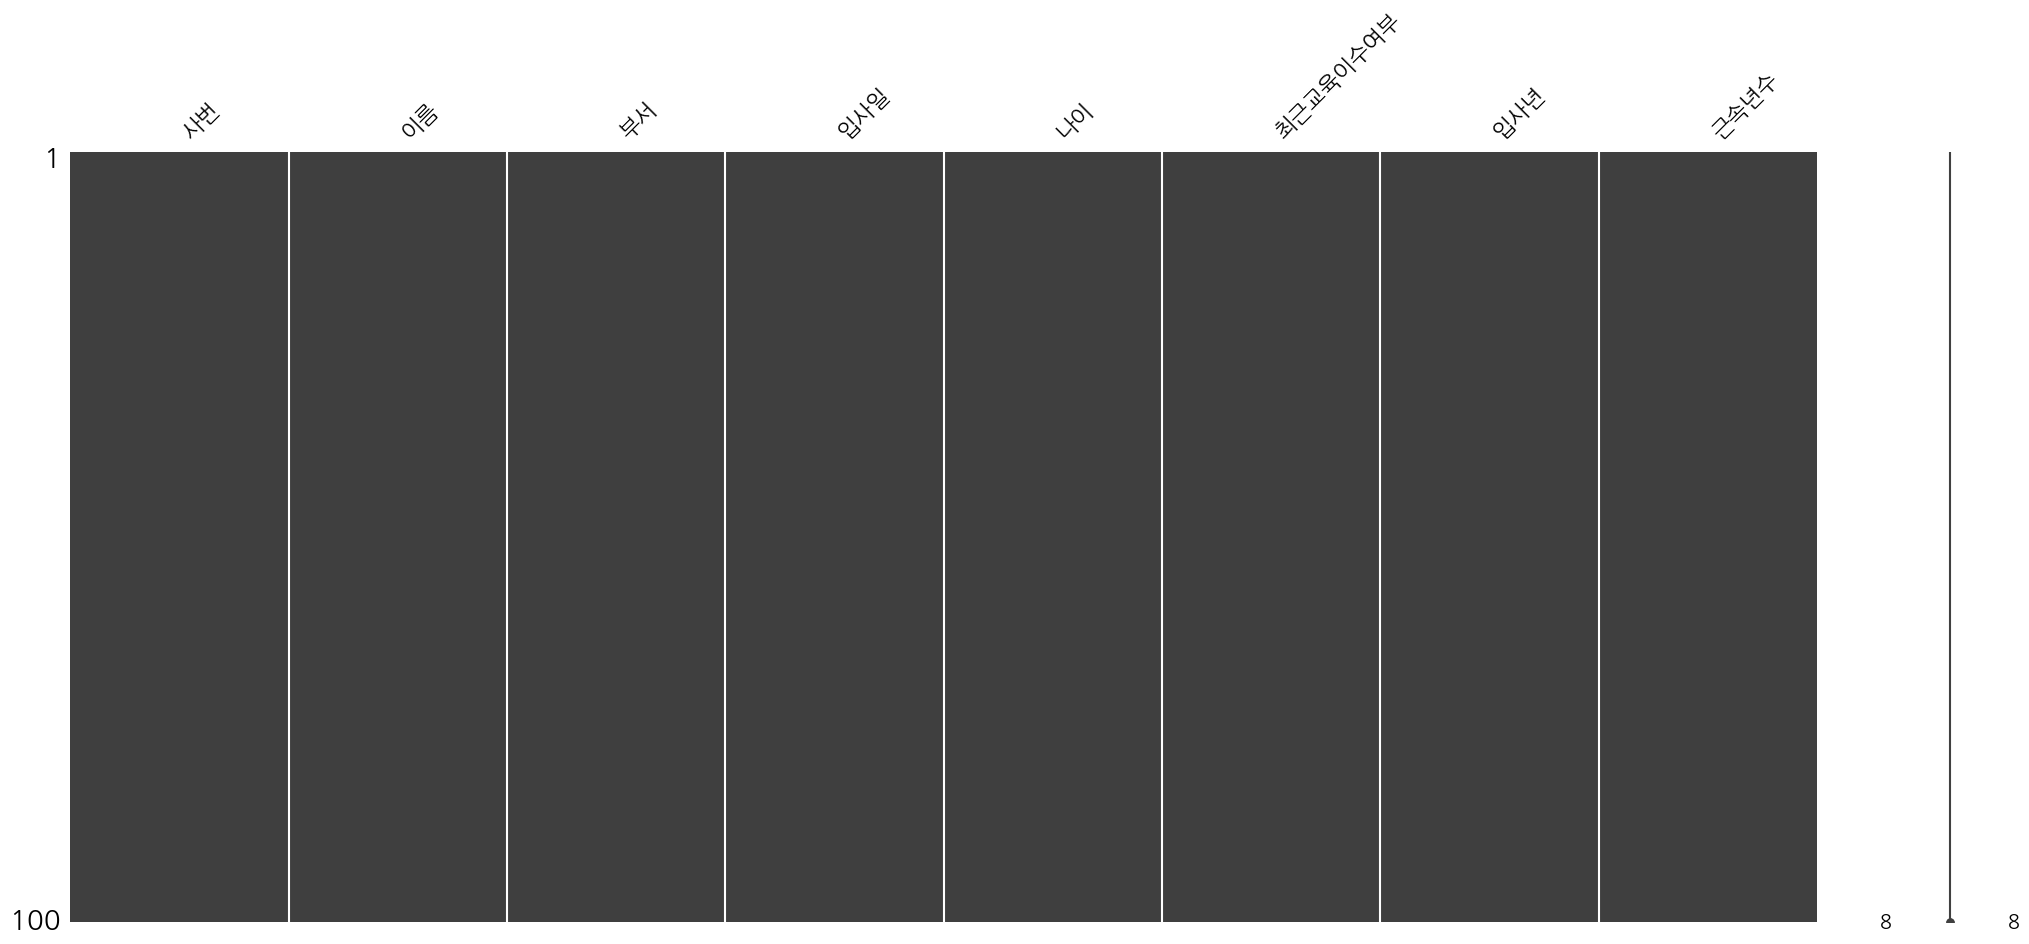

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(emp)

# msno.bar(df)
plt.show()

## 평가지표 — 정확도 · MSE  (슬라이드 14)

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error
# 오늘은 분류 문제이므로 accuracy_score를 사용합니다
# (회귀 문제라면 mean_squared_error를 사용)

## [실습] scikit-learn으로 결정트리 분류 모델 만들기  (슬라이드 15)

In [ ]:
# 부서(범주형)를 숫자로 바꾸고, 근속년수·나이와 합쳐서 특성 3종 구성
dept_dummies = pd.get_dummies(emp["부서"], prefix="부서")
X = pd.concat([emp[["근속년수", "나이"]], dept_dummies], axis=1)
y = emp["최근교육이수여부"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))
print(X.columns.tolist())


80 20
['근속년수', '나이', '부서_개발', '부서_마케팅', '부서_영업', '부서_인사', '부서_재무']


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
print("정확도(특성 3종):", tree_model.score(X_test, y_test))

정확도(특성 3종): 0.9


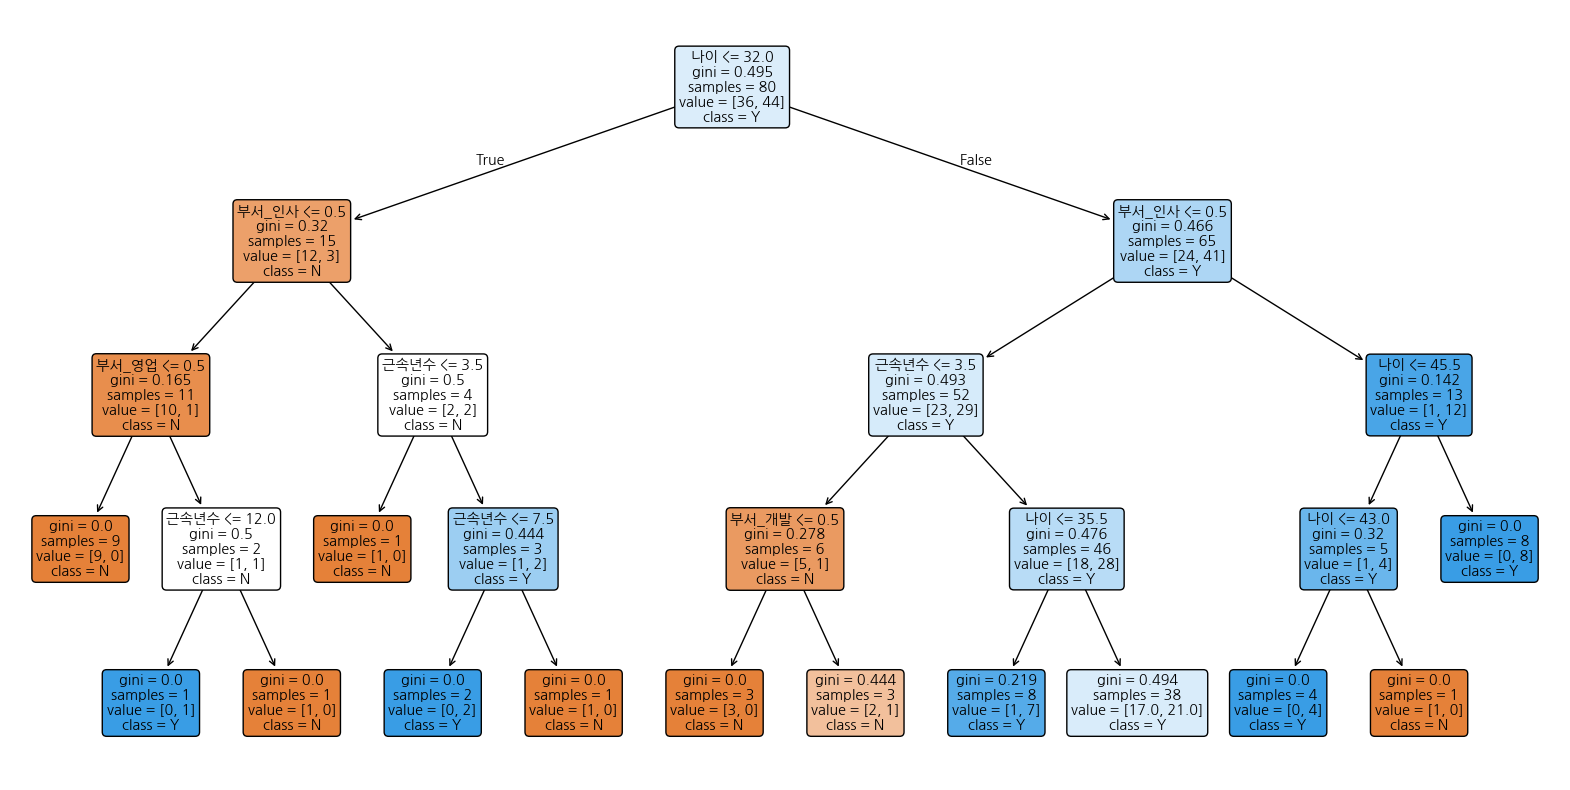

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns.tolist(), class_names=['N', 'Y'], filled=True, rounded=True)
plt.show()

쉽게 말하면,

"현재 이 노드에 서로 다른 클래스가 얼마나 섞여 있는가?"

를 나타내는 값입니다.

Gini = 0 → 한 클래스만 있음 → 완전히 순수
Gini가 클수록 → 여러 클래스가 섞여 있음 → 불순도가 높음

예를 들어 암석을 두 종류로 분류한다고 해볼게요.

노드	Sandstone	Shale	Gini
A	10	0	0
B	8	2	0.32
C	5	5	0.50

두 클래스 분류에서는 0.5가 최대값입니다.

In [ ]:
# y_train[X_train['나이']<=32]
y_train[(X_train['나이']>32) & (X_train['부서_인사'] == True ) & (X_train['나이']>45.5)]

,최근교육이수여부
72,Y
47,Y
7,Y
17,Y
67,Y
32,Y
52,Y
92,Y


In [ ]:
feature_importances = pd.Series(tree_model.feature_importances_, index=X.columns)
print("Feature Importances (결정 트리 모델):\n", feature_importances.sort_values(ascending=False))

Feature Importances (결정 트리 모델):
 나이        0.436775
근속년수      0.286235
부서_인사     0.212033
부서_영업     0.046154
부서_개발     0.018804
부서_마케팅    0.000000
부서_재무     0.000000
dtype: float64


In [ ]:
y_train

,최근교육이수여부
55,Y
88,N
26,Y
42,N
69,N
...,...
60,Y
71,Y
14,N
92,Y


### [비교] 특성 1개 vs 여러 개, 정확도 차이  (슬라이드 16)
같은 모델(DecisionTree)로, 특성 개수만 바꿔서 정확도를 직접 비교해봅니다.

In [ ]:
# 특성 1개(근속년수만)로 다시 학습
X1 = emp[["근속년수"]]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)
tree_model_1feat = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model_1feat.fit(X1_train, y1_train)

print("특성 1개(근속년수):", tree_model_1feat.score(X1_test, y1_test))
print("특성 3종(근속년수+나이+부서):", tree_model.score(X_test, y_test))

특성 1개(근속년수): 0.65
특성 3종(근속년수+나이+부서): 0.9


## 개념: 가중치와 편향, 숫자로 보면  (슬라이드 19)

In [ ]:
입력 = [2, 3]
가중치 = [0.5, 0.8]
편향 = 1

결과 = 입력[0]*가중치[0] + 입력[1]*가중치[1] + 편향
print(결과)  # 4.4

4.4


---
# Part IV-2. MLP 실습

## Keras로 MLP 모델 만들기  (슬라이드 26)

신경망 모델의 원리 이해하기

In [119]:
df = pd.read_excel("MLP_input.xlsx")
df
X = df["X"]
y = df["Y"]

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step - loss: 43.0816
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 20.3511
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 5.9411
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3924
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4.3132
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 9.1412
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.3910
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4.7785
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.6211
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3416
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.7382
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.9006
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.9950
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.5621
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.4813
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36

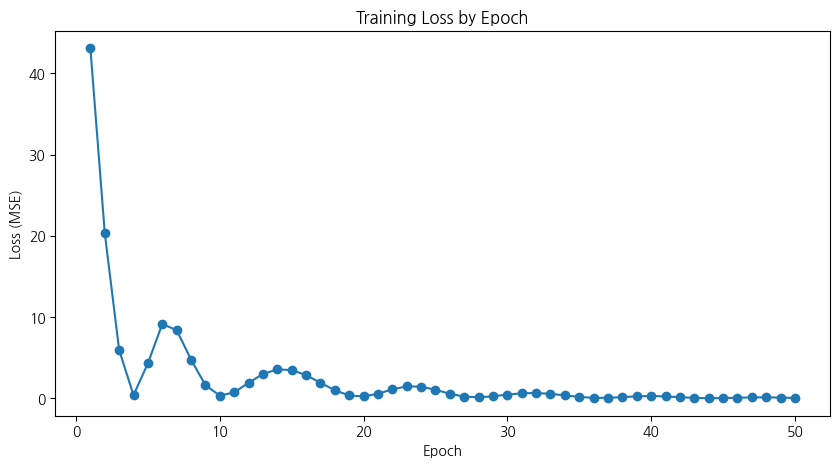

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
예측값: [[7.856334]]


In [120]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



mlp_model = Sequential([
    Dense(16, activation="relu", input_shape=(1,)),
    Dense(1)
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.1),
    loss="mse"
)

# 학습

history = mlp_model.fit(
    X,
    y,
    epochs=50,
    verbose=1
)

# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 51),
    history.history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss by Epoch")

plt.show()

# 4를 입력해서 예측
prediction = mlp_model.predict(np.array([[4]]))

print('예측값:', prediction)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - loss: 24.5768Epoch 1: 4의 예측값 = 12.8953, Loss = 24.5768
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step - loss: 24.5768
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 16.5929Epoch 2: 4의 예측값 = 9.5088, Loss = 16.5929
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 16.5929
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.9682Epoch 3: 4의 예측값 = 6.1324, Loss = 1.9682
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 1.9682
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.0348Epoch 4: 4의 예측값 = 4.8439, Loss = 2.0348
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 2.0348
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 5.9035Epoch 5: 4의 예측값 = 5.0097, Loss = 5.9035
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 5.9035
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 5.2848Epoch 6: 4의 예측값 = 6.1287, Loss = 5.2848
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - loss: 5.2848
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 2.0

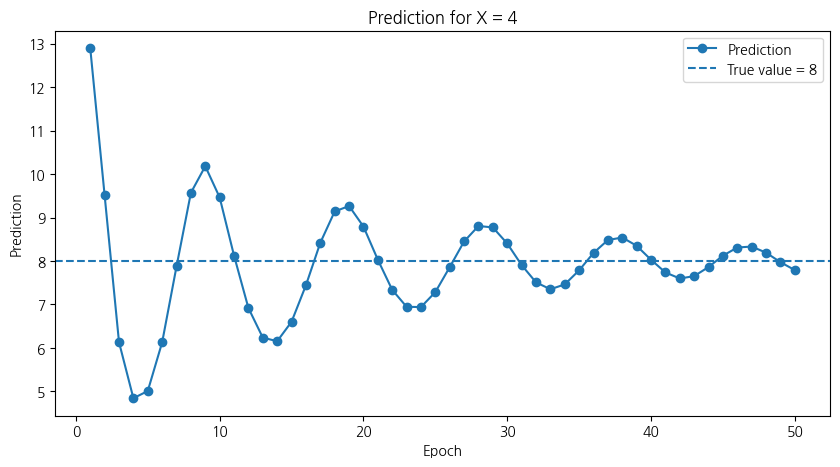

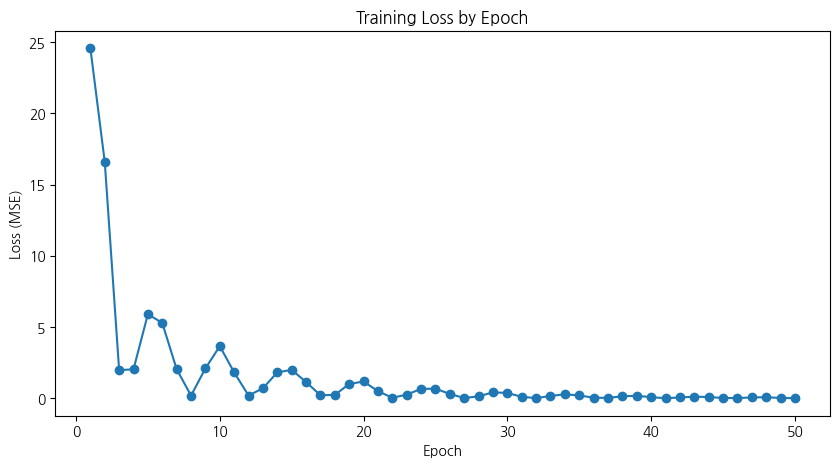

In [114]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adam


# =========================
# 1. 데이터
# =========================

# X = np.array([
#     [1],
#     [2],
#     [3],
#     [5]
# ])

# y = np.array([
#     [2],
#     [4],
#     [6],
#     [10]
# ])

# X = pd.DataFrame({"X": [1, 2, 3, 4]})

# y = pd.DataFrame({"y": [2, 4, 6, 8]})

# df = pd.read_excel("MLP_input.xlsx")

df = pd.read_excel("MLP_input.xlsx")
df
X = df["X"]
y = df["Y"]

# =========================
# 2. 신경망
# =========================

mlp_model = Sequential([
    Dense(16, activation="relu", input_shape=(1,)),
    Dense(1)
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.3),
    loss="mse"
)


# =========================
# 3. Epoch마다 4를 예측
# =========================

class PredictionMonitor(Callback):

    def __init__(self):
        super().__init__()
        self.predictions = []

    def on_epoch_end(self, epoch, logs=None):

        prediction = self.model.predict(
            np.array([[4]]),
            verbose=0
        )[0][0]

        self.predictions.append(prediction)

        print(
            f"Epoch {epoch + 1}: "
            f"4의 예측값 = {prediction:.4f}, "
            f"Loss = {logs['loss']:.4f}"
        )


monitor = PredictionMonitor()


# =========================
# 4. 학습
# =========================

history = mlp_model.fit(
    X,
    y,
    epochs=50,
    verbose=1,
    callbacks=[monitor]
)


# =========================
# 5. Epoch별 4의 예측값
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 51),
    monitor.predictions,
    marker="o",
    label="Prediction"
)

plt.axhline(
    y=8,
    linestyle="--",
    label="True value = 8"
)

plt.xlabel("Epoch")
plt.ylabel("Prediction")
plt.title("Prediction for X = 4")

plt.legend()
plt.show()


# =========================
# 6. Epoch별 Loss
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 51),
    history.history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss by Epoch")

plt.show()

## [실습] MLP 분류 모델 만들기  (슬라이드 27)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping



In [115]:
# 부서(범주형)를 숫자로 바꾸고, 근속년수·나이와 합쳐서 특성 3종 구성
dept_dummies = pd.get_dummies(emp["부서"], prefix="부서")
X = pd.concat([emp[["근속년수", "나이"]], dept_dummies], axis=1)
y = emp["최근교육이수여부"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))
print(X.columns.tolist())


80 20
['근속년수', '나이', '부서_개발', '부서_마케팅', '부서_영업', '부서_인사', '부서_재무']


In [117]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

mlp_model = Sequential([
    Dense(16, activation="relu"),
    # Dense(1, activation="sigmoid"),
    Dense(1),

])

In [118]:
X_train_arr = X_train.values.astype("float32")
X_test_arr = X_test.values.astype("float32")
y_train_arr = (y_train == "Y").astype(int).values
y_test_arr = (y_test == "Y").astype(int).values

mlp_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = mlp_model.fit(X_train_arr, y_train_arr, epochs=20, verbose=1, validation_split=0.2)
mlp_model.evaluate(X_test_arr, y_test_arr)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss: 7.9712
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5625 - loss: 6.9748 - val_accuracy: 0.5000 - val_loss:

[5.579834938049316, 0.6499999761581421]

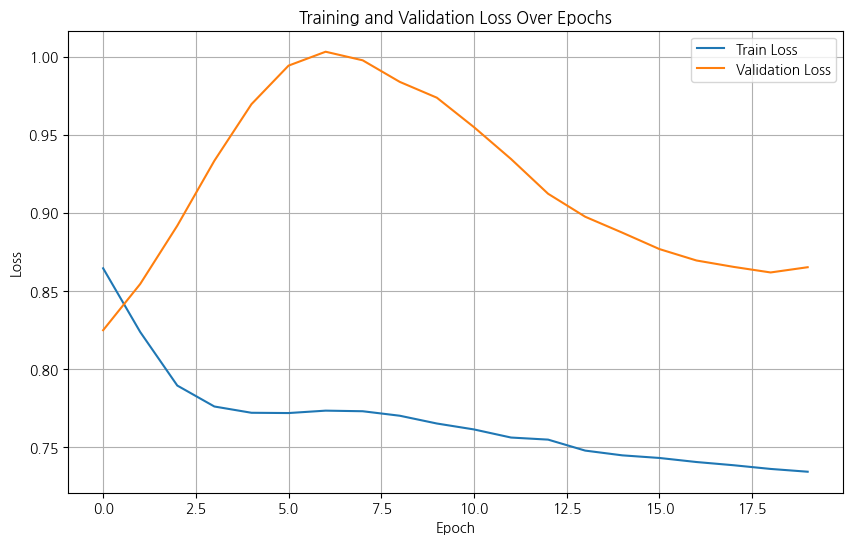

In [ ]:
import matplotlib.pyplot as plt

# 손실(Loss) 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# EarlyStopping 콜백 정의
# monitor='val_loss': 검증 손실을 모니터링합니다.
# patience=5: 5 에포크 동안 검증 손실이 개선되지 않으면 학습을 중단합니다.
# restore_best_weights=True: 학습 중 가장 좋았던 가중치를 복원합니다.
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)

history_early_stop = mlp_model.fit(X_train_arr, y_train_arr, epochs=100, verbose=1, validation_split=0.2, callbacks=[early_stopping])
print("MLP 모델 평가 (Early Stopping 적용 후):")
mlp_model.evaluate(X_test_arr, y_test_arr)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5312 - loss: 0.7301 - val_accuracy: 0.3750 - val_loss: 0.8632
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5312 - loss: 0.7280 - val_accuracy: 0.3750 - val_loss: 0.8647
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5312 - loss: 0.7261 - val_accuracy: 0.3750 - val_loss: 0.8665
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5312 - loss: 0.7228 - val_accuracy: 0.3750 - val_loss: 0.8653
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5312 - loss: 0.7209 - val_accuracy: 0.3750 - val_loss: 0.8633
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5312 - loss: 0.7189 - val_accuracy: 0.3750 - val_loss: 0.8587
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5469 - loss: 0.7164 - val_accuracy: 0.4375 - val_loss: 0.8559
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5312 - loss: 0.7151 - val_accuracy: 0.3750 - val_loss

[0.53785640001297, 0.699999988079071]

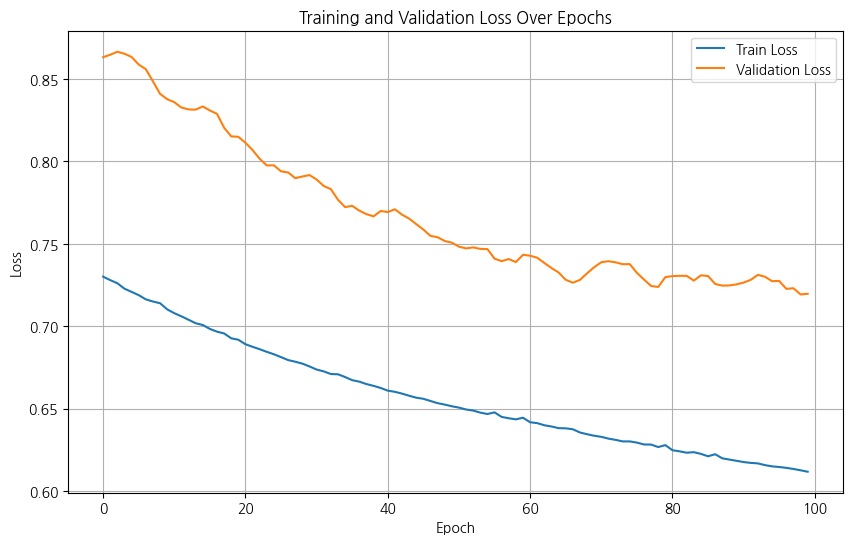

In [ ]:
import matplotlib.pyplot as plt

# 손실(Loss) 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(history_early_stop.history['loss'], label='Train Loss')
plt.plot(history_early_stop.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## [실습] 하이퍼파라미터 바꿔보기  (슬라이드 29)

In [ ]:
model2 = Sequential([
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])
model2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)

history_early_stop_2 = model2.fit(X_train_arr, y_train_arr, epochs=100, verbose=1, validation_split=0.2, callbacks=[early_stopping])
print(model2.evaluate(X_test_arr, y_test_arr))

# TODO: Dense의 숫자(뉴런 수)를 다른 값으로 바꿔서 다시 실행해보세요


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.5781 - loss: 0.7687 - val_accuracy: 0.4375 - val_loss: 0.7763
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5000 - loss: 0.7708 - val_accuracy: 0.5000 - val_loss: 0.7589
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5156 - loss: 0.7447 - val_accuracy: 0.3750 - val_loss: 0.7978
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6094 - loss: 0.6685 - val_accuracy: 0.5000 - val_loss: 0.8938
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5781 - loss: 0.7013 - val_accuracy: 0.5000 - val_loss: 0.9402
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5625 - loss: 0.6975 - val_accuracy: 0.5000 - val_loss: 0.8386
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5938 - loss: 0.6648 - val_accuracy: 0.5000 - val_loss: 0.7445
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6875 - loss: 0.6610 - val_accuracy: 0.6250 - val

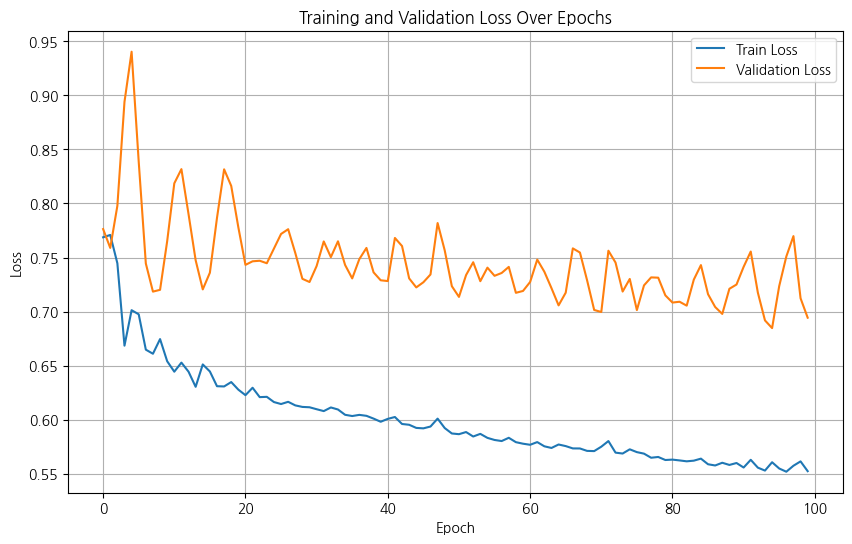

In [ ]:
import matplotlib.pyplot as plt

# 손실(Loss) 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(history_early_stop_2.history['loss'], label='Train Loss')
plt.plot(history_early_stop_2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

---
# Part IV-3. CNN 실습

## [실습] MNIST 데이터 불러오기 & 확인  (슬라이드 37)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


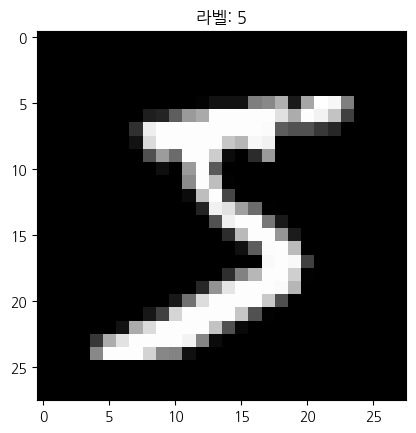

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()
print(X_train_img.shape)  # (60000, 28, 28)

plt.imshow(X_train_img[0], cmap="gray")
plt.title(f"라벨: {y_train_img[0]}")
plt.show()

## CNN 모델 구조 설계하기  (슬라이드 38)

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

X_train_img_n = X_train_img.reshape(-1, 28, 28, 1) / 255.0
X_test_img_n = X_test_img.reshape(-1, 28, 28, 1) / 255.0

cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation="softmax"),
])

## [실습] CNN 모델 만들고 학습시키기  (슬라이드 39)

In [ ]:
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(X_train_img_n[:5000], y_train_img[:5000], epochs=3, verbose=1)
cnn.evaluate(X_test_img_n[:1000], y_test_img[:1000])

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8174 - loss: 0.7155
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9180 - loss: 0.2851
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9396 - loss: 0.2175
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9260 - loss: 0.2583


[0.25831905007362366, 0.9259999990463257]

## [실습] 예측 결과 시각화하기  (슬라이드 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


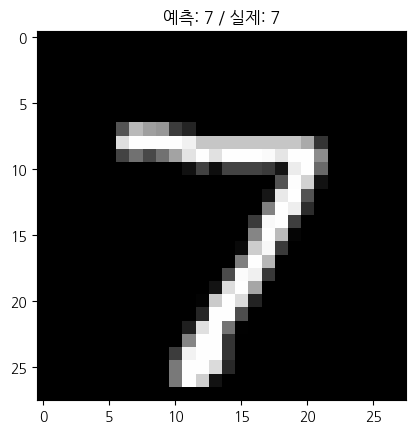

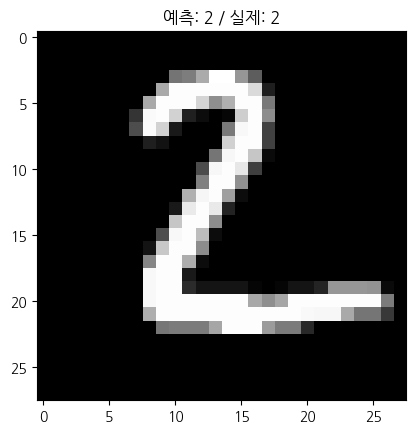

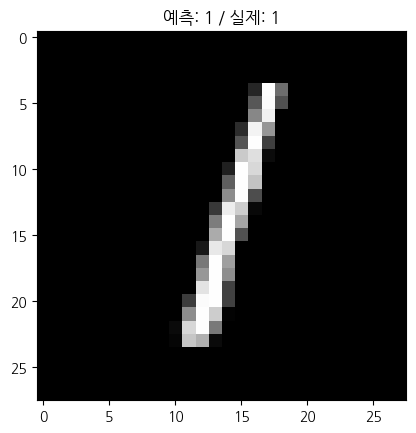

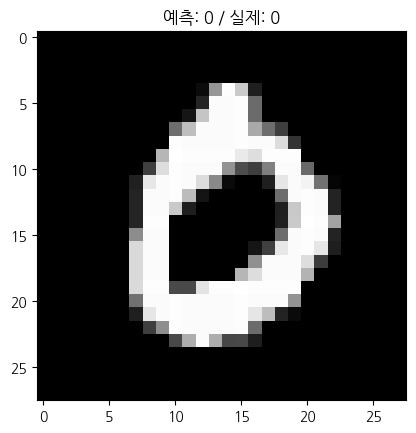

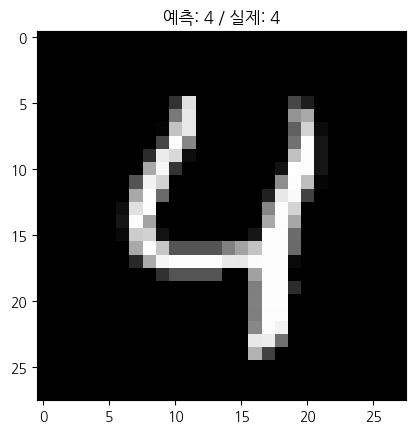

In [ ]:
예측 = cnn.predict(X_test_img_n[:5])

for i in range(5):
    plt.imshow(X_test_img[i], cmap="gray")
    plt.title(f"예측: {예측[i].argmax()} / 실제: {y_test_img[i]}")
    plt.show()

---
# Part IV-4. LSTM 실습

## [실습] 간단한 시계열 데이터 준비하기  (슬라이드 47)

In [121]:
perf

,지점명,담당자,판매건수,매출액,월
0,서울점,김O,17,6760203,1월
1,부산점,이O,21,6282969,1월
2,대구점,박O,23,9526600,1월
3,인천점,최O,33,10667019,1월
4,광주점,정O,44,16265348,1월
5,서울점,김O,15,6122670,2월
6,부산점,이O,24,6966648,2월
7,대구점,박O,33,9911451,2월
8,인천점,최O,40,14489880,2월
9,광주점,정O,38,14128286,2월


In [124]:
월별합계 = perf.groupby("월", sort=False)["매출액"].sum()    # 에러나면 붙이기   .values.astype("float32")
scale = 월별합계.max()
series = 월별합계 / scale  # 0~1 사이로 정규화


월별합계

,매출액
월,
1월,49502139
2월,51618935
3월,49497643
4월,51516223
5월,46172959
6월,46831317
7월,48551998
8월,49251878
9월,46085078


In [125]:
series

,매출액
월,
1월,0.958992
2월,1.000000
3월,0.958905
4월,0.998010
5월,0.894497
6월,0.907251
7월,0.940585
8월,0.954144
9월,0.892794


In [ ]:

window = 3  # 지난 3개월로 다음 달을 예측
X_seq, y_seq = [], []
for i in range(len(series) - window):
    X_seq.append(series[i:i+window])
    y_seq.append(series[i+window])
X_seq = np.array(X_seq).reshape(-1, window, 1)
y_seq = np.array(y_seq)

split = int(len(X_seq) * 0.7)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]
print(X_seq.shape)

(9, 3, 1)


/tmp/ipykernel_1108/4039680312.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(series[i+window])


In [ ]:
월별합계 = perf.groupby("월", sort=False)["매출액"].sum()
월별합계

,매출액
월,
1월,49502139
2월,51618935
3월,49497643
4월,51516223
5월,46172959
6월,46831317
7월,48551998
8월,49251878
9월,46085078


## [실습] LSTM 모델 만들고 학습시키기  (슬라이드 48)

In [ ]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(32, activation="relu"),
    Dense(1),
])
lstm.compile(optimizer="adam", loss="mse")

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
history_early_stop_3 = lstm.fit(X_train_seq, y_train_seq, epochs=200, verbose=1, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.7646 - val_loss: 0.7328
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.7504 - val_loss: 0.7190
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.7361 - val_loss: 0.7056
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.7221 - val_loss: 0.6922
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.7082 - val_loss: 0.6788
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.6943 - val_loss: 0.6652
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.6804 - val_loss: 0.6518
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.6666 - val_loss: 0.6384
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.6527 - val_loss: 0.6251
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.6389 - val_loss: 0.6118
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.6251 - val_loss: 0.5985
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.6113 - val_loss

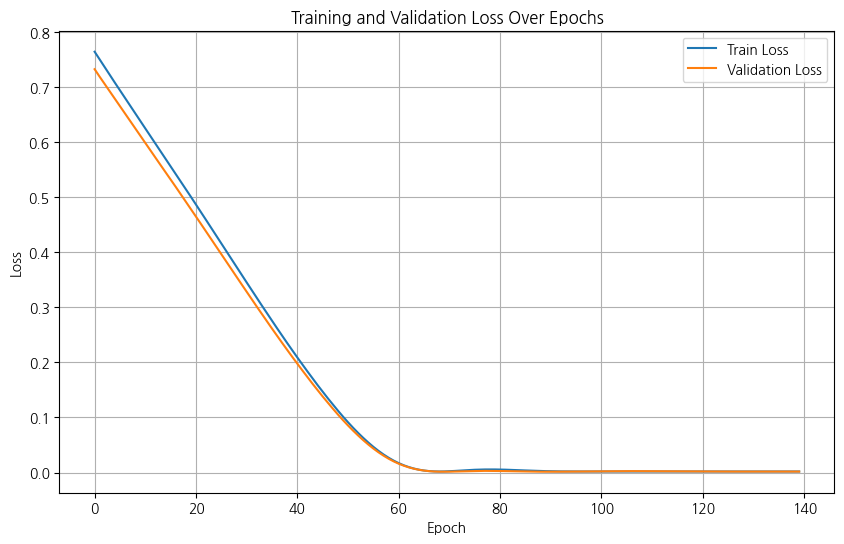

In [ ]:
import matplotlib.pyplot as plt

# 손실(Loss) 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(history_early_stop_3.history['loss'], label='Train Loss')
plt.plot(history_early_stop_3.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 결과 확인 & 예측 그래프 그리기  (슬라이드 49)

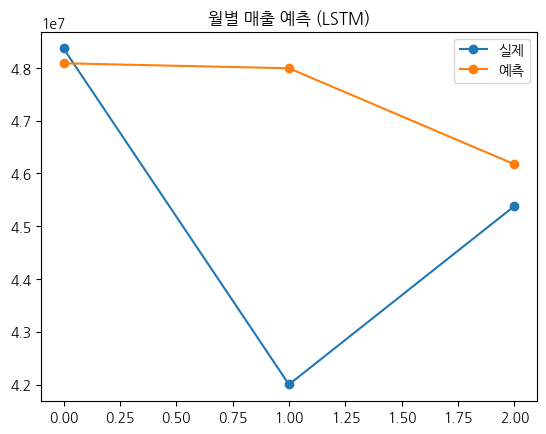

In [ ]:
예측_seq = lstm.predict(X_test_seq, verbose=0)

plt.plot(y_test_seq * scale, label="실제", marker="o")
plt.plot(예측_seq.flatten() * scale, label="예측", marker="o")
plt.legend()
plt.title("월별 매출 예측 (LSTM)")
plt.show()

---
# Part IV-5. 종합

수고하셨습니다! 오늘 만든 모델들을 정리해볼까요?

In [ ]:
print("DecisionTree 정확도 (특성 1개):", tree_model_1feat.score(X1_test, y1_test))
print("DecisionTree 정확도 (특성 3종):", tree_model.score(X_test, y_test))
print("MLP 정확도:", mlp_model.evaluate(X_test_arr, y_test_arr, verbose=0)[1])
print("CNN 정확도:", cnn.evaluate(X_test_img_n[:1000], y_test_img[:1000], verbose=0)[1])

DecisionTree 정확도 (특성 1개): 0.65
DecisionTree 정확도 (특성 3종): 0.9
MLP 정확도: 0.699999988079071
CNN 정확도: 0.9259999990463257
